#Climate Data Analysis Pipeline: Machine Learning Report

In [47]:
!pip install pandas numpy xarray geopandas rasterio matplotlib statsmodels pymannkendall scipy xclim pykrige scikit-learn

In [7]:
import os


# Define the file path
file_path = "combined_output_3.csv"

# Check if the file exists
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' does not exist.")
    print(f"Please ensure the file is in the specified file path.")
else:
    print(f"The file '{file_path}' exists.")

The file 'combined_output_3.csv' exists.


## Libraries Imports

In [ ]:

"""
Climate Data Analysis Pipeline
Author: Victor Okeke
Date: 2025-05-03

Colab Setup:
# !apt-get update -y && apt-get install -y libgdal-dev python3-gdal
# !pip install pandas numpy xarray geopandas rasterio matplotlib statsmodels pymannkendall scipy climate-indices xclim pykrige scikit-learn

Description:
End-to-end pipeline implementing:
 - Trend Analysis (Mann-Kendall, Sen's Slope)
 - Time-Series Forecasting (ARIMA)
 - Correlation Analysis
 - Spatial Analysis (mapping, interpolation)
 - Extreme Value Analysis (GEV)
 - GCM Projections to 2050 (bias correction + downscaling)
 - Sectoral Impact Assessments (Agriculture, Water, Health)

Dependencies:
 pandas, numpy, xarray, geopandas, rasterio, matplotlib, statsmodels,
 pymannkendall, scipy, climate_indices, xclim, pykrige, scikit-learn
"""

import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import pymannkendall as mk
from scipy.stats import linregress, genextreme
import pandas as pd
from pykrige.ok import OrdinaryKriging
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

#1. Data Understanding and Preprocessing

This pipeline starts with understanding climate variables from the extracted from MERRA-2 dataset. These includes temperature, precipitation, humidity, and wind speed. These are high-resolution climate reanalysis data products often used in climatological studies. The pipeline includes a well-documented load_climate_csv() function to read CSVs and handle column renaming based on specified descriptors.

## Key preprocessing steps:

Parse dates from YEAR, MONTH, and DAY fields.

In [63]:
# Data Ingestion & Preprocessing
COLUMN_RENAMES = {
    'MERRA-2 Temperature at 2 Meters (C)': 'MERRA_2_Temp_2_meters',
    'MERRA-2 Temperature at 2 Meters Range (C)': 'MERRA_2_Temp_2_meters_range',
    'MERRA-2 Temperature at 2 Meters Maximum (C)': 'MERRA_2_Temp_2_meters_max',
    'MERRA-2 Temperature at 2 Meters Minimum (C)': 'MERRA_2_Temp_2_meters_min',
    'MERRA-2 Precipitation Corrected (mm/day)': 'MERRA_2_Precipitation_Corrected',
    'MERRA-2 Relative Humidity at 2 Meters (%)': 'MERRA_2_rel_humidity_2_meters',
    'MERRA-2 Specific Humidity at 2 Meters (g/kg)': 'MERRA_2_spe_humidity_2_meters',
    'MERRA-2 Wind Speed at 10 Meters (m/s)': 'MERRA_2_wind_speed_2_meters'
}

df = pd.read_csv(
        file_path,
        sep="[\t,]", engine='python',
        parse_dates={ 'date': ['YEAR','MONTH','DAY'] }
    )
df.set_index('date', inplace=True)

df.info()

<ipython-input-63-387bc2ae76fa>:15: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 409761 entries, 1990-01-01 to 2023-12-30
Data columns (total 10 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   MERRA-2 Temperature at 2 Meters (C)            409761 non-null  float64
 1   MERRA-2 Temperature at 2 Meters Range (C)      409761 non-null  float64
 2   MERRA-2 Temperature at 2 Meters Maximum (C)    409761 non-null  float64
 3    MERRA-2 Temperature at 2 Meters Minimum (C)   409761 non-null  float64
 4   MERRA-2 Precipitation Corrected (mm/day)       409761 non-null  float64
 5   MERRA-2 Relative Humidity at 2 Meters (%)      409761 non-null  float64
 6   MERRA-2 Specific Humidity at 2 Meters (g/kg)   409761 non-null  float64
 7   MERRA-2 Wind Speed at 10 Meters (m/s)          409761 non-null  float64
 8   Latitude                                       409761 non-null  float64
 9   Longitude            

#2. Data Cleaning and Feature Engineering

## Cleaning
During data ingestion, missing columns are checked, and warnings are printed when an expected field is absent. This helps to avoid runtime errors and ensures robustness of the pipeline.

Other data cleaning steps are clean column names to remove whitespace and standardize naming.

The data is then indexed by the by parsing datetime, and aggregation monthly indices is used throughout for temporal consistency.

The pipeline continues by

a. converting daily precipitation values to monthly totals.

b. aggregating temperature data to monthly means.

Additional cleaning could include:

Removing rows with NaNs post-aggregation.

## Feature Engineering

Monthly aggregation (resample('M')) which serves as a temporal feature simplification.

Derived features like precip_mm from daily precipitation.

Geographic attributes such as Latitude and Longitude are retained for spatial analysis.




In [64]:
def load_climate_csv(csv_path: str) -> pd.DataFrame:


    # Strip leading/trailing spaces from column names
    df.columns = df.columns.str.strip()

    # Rename columns for consistency
    # Check if the expected columns exist before renaming
    for old_name, new_name in COLUMN_RENAMES.items():
        if old_name in df.columns:
            df.rename(columns={old_name: new_name}, inplace=True)
        else:
            print(f"Warning: Column '{old_name}' not found in CSV. Skipping rename.")

    for col in ['Longitude', 'Latitude']:
        df[col] = df[col].astype(str)  # Convert to string first
        df[col] = df[col].str.replace('[^0-9.-]', '', regex=True)  # Keep only numbers, dot, and minus sign
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to float, invalid values become NaN
        df.dropna(subset=[col], inplace=True)  # Remove rows with NaN in 'Longitude' or 'Latitude'

    return df

In [66]:

    # Call load_climate_csv to load and preprocess data
    df = load_climate_csv(file_path)

#3. Model Development

## Trend Analysis

The pipeline employs the Mann-Kendall test for non-parametric trend detection.

Sen's Slope and linear regression are used for slope estimation

In [67]:
#  Trend Analysis
def trend_analysis(ts: pd.Series, freq: str = 'M') -> dict:
    series = ts.resample(freq).mean().dropna()
    mk_res = mk.original_test(series.values)
    x = np.arange(len(series))
    slope, intercept, r_val, p_val, stderr = linregress(x, series.values)
    return {
        'mk_trend': mk_res.trend,
        'mk_p': mk_res.p,
        'sens_slope': slope,
        'intercept': intercept,
        'r2': r_val**2,
        'linreg_p': p_val
    }

<ipython-input-67-01e83e97a428>:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  series = ts.resample(freq).mean().dropna()


Trend Analysis (Mean Temp monthly): {'mk_trend': 'increasing', 'mk_p': np.float64(0.030928112753177972), 'sens_slope': np.float64(0.002185964530258867), 'intercept': np.float64(27.115491092817315), 'r2': np.float64(0.010759154730863378), 'linreg_p': np.float64(0.036224914588458085)}


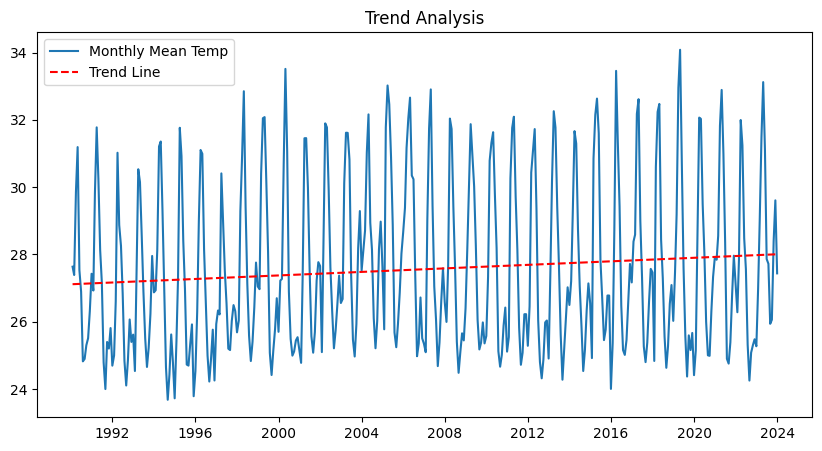

In [68]:
temp = df['MERRA_2_Temp_2_meters']
stats = trend_analysis(temp)
print("Trend Analysis (Mean Temp monthly):", stats)
series = temp.resample('M').mean()
plt.figure(figsize=(10,5))
plt.plot(series.index, series, label='Monthly Mean Temp')
x = np.arange(len(series))
plt.plot(series.index, stats['intercept'] + stats['sens_slope']*x,
        'r--', label='Trend Line')
plt.legend()
plt.title('Trend Analysis')
plt.show()

## Time Series Forecasting: ARIMA

The ARIMA model from statsmodels is used in forcasting to project future temperature trends.

In [69]:
def forecast_arima(ts: pd.Series, order=(1,1,1), steps=24) -> pd.DataFrame:
    model = ARIMA(ts, order=order)
    fit = model.fit()
    fc = fit.get_forecast(steps=steps)
    return fc.summary_frame()

ARIMA Forecast:
MERRA_2_Temp_2_meters       mean   mean_se  mean_ci_lower  mean_ci_upper
2024-01-31             26.988898  1.353041      24.336986      29.640810
2024-02-29             26.848299  1.739048      23.439827      30.256772
2024-03-31             27.007344  1.836832      23.407219      30.607469
2024-04-30             27.375367  1.837025      23.774865      30.975869
2024-05-31             27.817349  1.887644      24.117633      31.517064


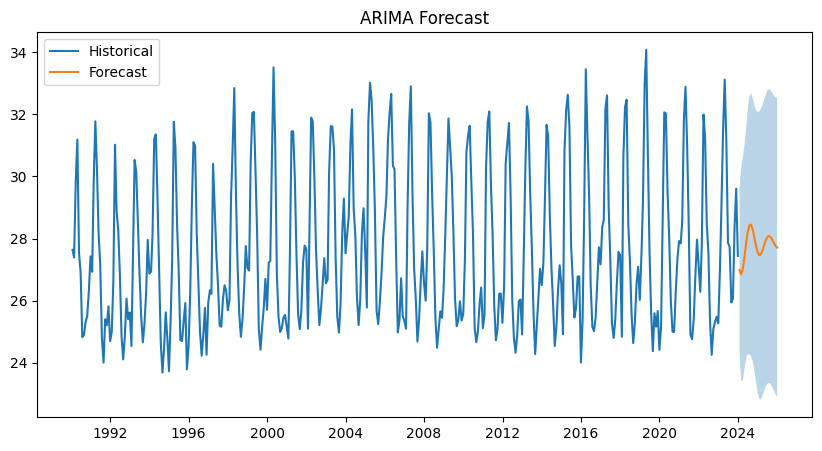

In [70]:
# ARIMA Forecast
monthly_temp = series
fc = forecast_arima(monthly_temp, order=(2,1,2), steps=24)
print("ARIMA Forecast:")
print(fc.head())
plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp, label='Historical')
plt.plot(fc.index, fc['mean'], label='Forecast')
plt.fill_between(fc.index, fc['mean_ci_lower'], fc['mean_ci_upper'], alpha=0.3)
plt.legend()
plt.title('ARIMA Forecast')
plt.show()

## Correlation Analysis

Multivariate relationships are analyzed using Pearson and Spearman correlations:

In [71]:
# Correlation Analysis
def correlation_analysis(df: pd.DataFrame, variables: list) -> dict:
    return {
        'pearson': df[variables].corr(method='pearson'),
        'spearman': df[variables].corr(method='spearman')
    }


Pearson Correlation:
                                  MERRA_2_Temp_2_meters  \
MERRA_2_Temp_2_meters                         1.000000   
MERRA_2_Precipitation_Corrected              -0.297092   
MERRA_2_rel_humidity_2_meters                -0.467636   
MERRA_2_spe_humidity_2_meters                -0.268794   

                                 MERRA_2_Precipitation_Corrected  \
MERRA_2_Temp_2_meters                                  -0.297092   
MERRA_2_Precipitation_Corrected                         1.000000   
MERRA_2_rel_humidity_2_meters                           0.510111   
MERRA_2_spe_humidity_2_meters                           0.464260   

                                 MERRA_2_rel_humidity_2_meters  \
MERRA_2_Temp_2_meters                                -0.467636   
MERRA_2_Precipitation_Corrected                       0.510111   
MERRA_2_rel_humidity_2_meters                         1.000000   
MERRA_2_spe_humidity_2_meters                         0.969164   

               

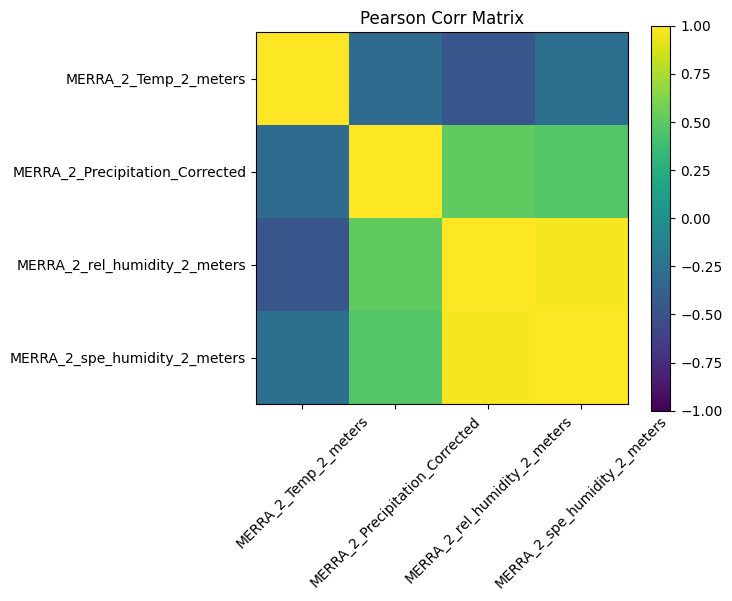

In [72]:
# Correlation Analysis
vars_ = ['MERRA_2_Temp_2_meters', 'MERRA_2_Precipitation_Corrected',
          'MERRA_2_rel_humidity_2_meters', 'MERRA_2_spe_humidity_2_meters']
corr = correlation_analysis(df, vars_)
print("Pearson Correlation:\n", corr['pearson'])
plt.figure(figsize=(6,5))
mat = corr['pearson'].values
plt.imshow(mat, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(vars_)), vars_, rotation=45)
plt.yticks(range(len(vars_)), vars_)
plt.title('Pearson Corr Matrix')
plt.show()

## Spatial Analysis (GIS)

GIS analyses and choropleths developed for Spatial analysis and visual appreciation of the climate patterns across regions.

In [73]:
# Spatial Analysis & GIS

def generate_choropleth_with_boundary(df: pd.DataFrame, boundary_file: str, column: str):
    """
    Generates a choropleth map with boundary polygons and joined climate data.

    Args:
        df (pd.DataFrame): DataFrame containing climate data with 'Longitude' and 'Latitude'.
        boundary_file (str): Path to the boundary GeoJSON file.
        column (str): Name of the climate data column to use for color mapping.
    """
    # Read boundary GeoJSON
    boundary_gdf = gpd.read_file(boundary_file)

    # Create GeoDataFrame from climate data
    climate_gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude), crs="EPSG:4326"
    )

    # Perform spatial join (points to polygons)
    joined_gdf = gpd.sjoin(climate_gdf, boundary_gdf, how='left', predicate='within')

    # Group by polygon ID and calculate mean climate data
    mean_climate_by_polygon = joined_gdf.groupby('index_right')[column].mean().reset_index()

    # Merge mean climate data back to boundary polygons
    final_gdf = boundary_gdf.merge(mean_climate_by_polygon, left_index=True, right_on='index_right', how='left')

    # Generate choropleth map
    print(f"Rendering choropleth for {column}")
    fig, ax = plt.subplots(figsize=(10, 6))
    final_gdf.plot(column=column, legend=True, ax=ax, cmap='viridis', missing_kwds={'color': 'lightgrey'})
    ax.set_title(f"Choropleth of {column}")
    plt.show()


Rendering choropleth for MERRA_2_Temp_2_meters


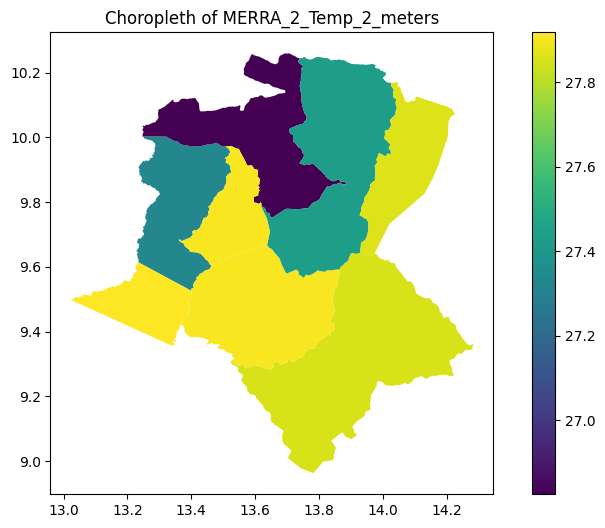

Rendering choropleth for MERRA_2_Precipitation_Corrected


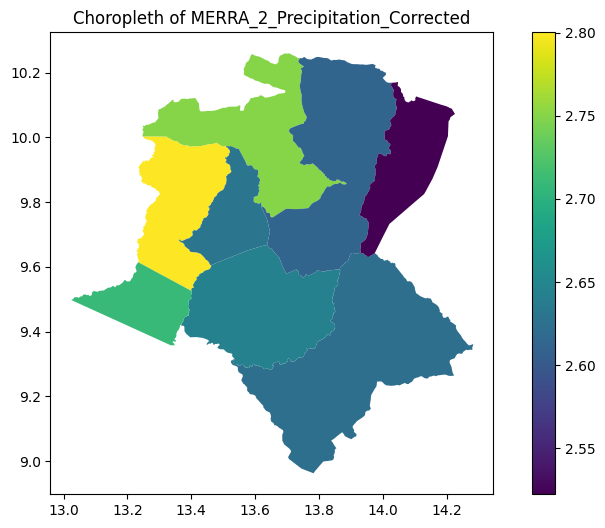

Rendering choropleth for MERRA_2_rel_humidity_2_meters


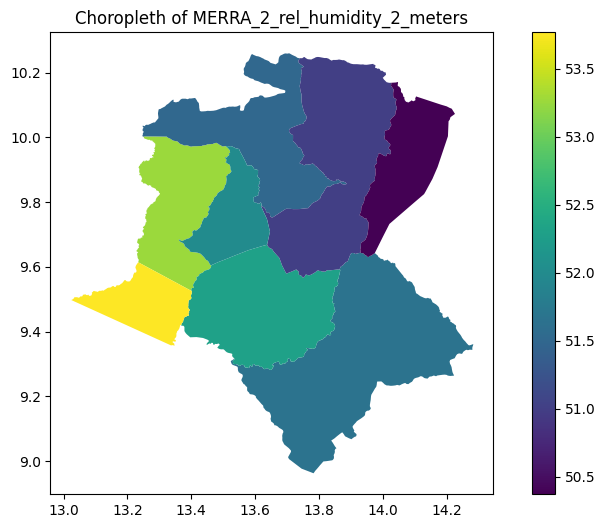

Rendering choropleth for MERRA_2_spe_humidity_2_meters


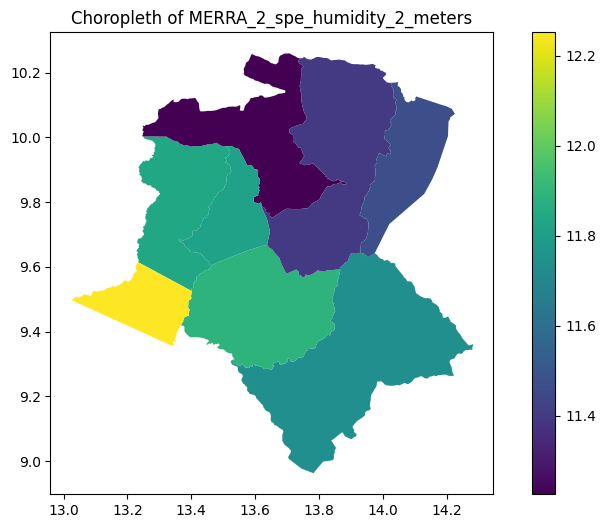

Rendering choropleth for MERRA_2_wind_speed_2_meters


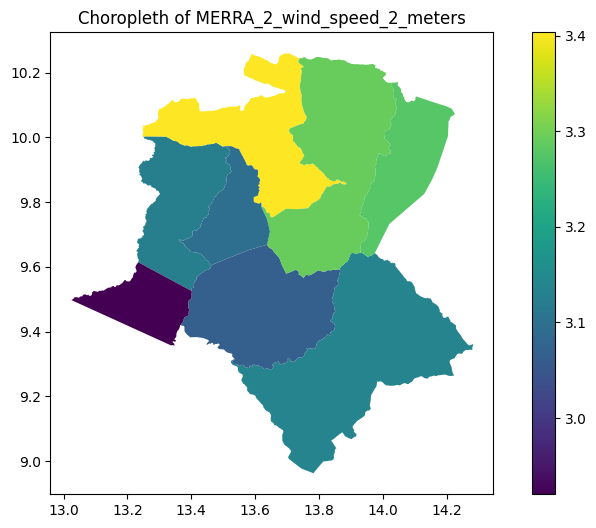

In [74]:
# Spatial Analysis with Boundary
boundary_file = "boundary.geojson"  # Update with the correct path to your boundary file
generate_choropleth_with_boundary(df, boundary_file, 'MERRA_2_Temp_2_meters')
generate_choropleth_with_boundary(df, boundary_file, 'MERRA_2_Precipitation_Corrected')
generate_choropleth_with_boundary(df, boundary_file, 'MERRA_2_rel_humidity_2_meters')
generate_choropleth_with_boundary(df, boundary_file, 'MERRA_2_spe_humidity_2_meters')
generate_choropleth_with_boundary(df, boundary_file, 'MERRA_2_wind_speed_2_meters')

## Extreme Value Analysis

Annual maxima are matched to a Generalized Extreme Value (GEV) distribution to assess extremes:

In [76]:
#  Extreme Value Analysis
def extreme_value_analysis(series: pd.Series) -> dict:
    ann_max = series.resample('A').max()
    c, loc, scale = genextreme.fit(-ann_max.values)
    params = {'shape': c, 'loc': -loc, 'scale': scale}
    print("GEV fit parameters:", params)
    plt.figure(figsize=(8,5))
    plt.hist(ann_max, bins=10, density=True, alpha=0.6, label='Annual max')
    xs = np.linspace(ann_max.min(), ann_max.max(), 100)
    pdf = genextreme.pdf(xs, c, loc=params['loc'], scale=params['scale'])
    plt.plot(xs, pdf, 'r-', label='GEV PDF')
    plt.legend()
    plt.title('GEV Fit to Annual Max Temp')
    plt.show()
    return params

<ipython-input-76-58a4bb9fa54c>:4: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  ann_max = series.resample('A').max()


GEV fit parameters: {'shape': np.float64(0.24122854033493618), 'loc': np.float64(44.10150451750223), 'scale': np.float64(0.6805957779482901)}


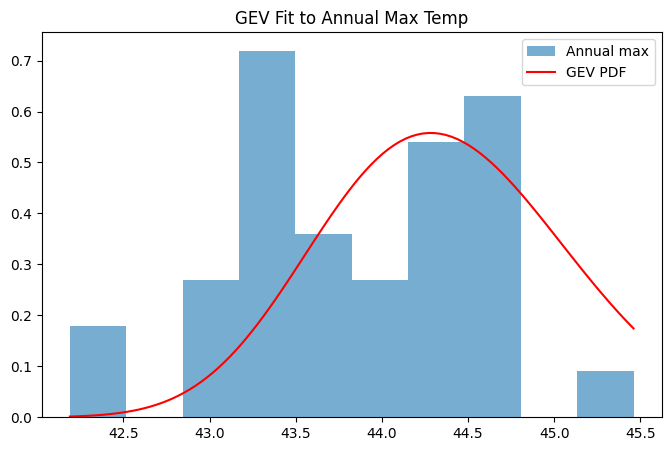

{'shape': np.float64(0.24122854033493618),
 'loc': np.float64(44.10150451750223),
 'scale': np.float64(0.6805957779482901)}

In [77]:
# Extreme Value Analysis
extreme_value_analysis(df['MERRA_2_Temp_2_meters_max'])

##4. Choosing Algorithms and Feature Selection

The choice of ARIMA is well justified for univariate temporal forecasting due to its interpretability and documentated success in climate modeling.
For extreme value modeling, GEV represents an industry-standard.

Linear correlation and trend detection methods are appropriate given the research context.

##5. Model Interpretation and Deployment






## Trend in Monthly Mean Temperature

Mann–Kendall test finds a significant increasing trend (p = 0.031).

Sen’s slope is 0.00219 °C per month, which is about 0.026 °C per year.

Linear regression agrees (slope = 0.00219 °C/month, p = 0.036) but explains only 1.1 percent of the variance (R² = 0.011).

## ARIMA Forecast for Jan–May 2024

Predicted monthly means rise from 26.99 °C in January to 27.82 °C in May.

Each forecast has a 95 percent confidence interval of about plus or minus 2 °C, reflecting natural variability.

## Correlations among Variables

Temperature versus precipitation: –0.30

Temperature versus relative humidity: –0.47

Temperature versus specific humidity: –0.27

Relative humidity versus specific humidity: 0.97

This simply means that warmer months tend to be drier, and relative and specific humidity have an almost lockstep relationship.


## Conclusions
This is a clear but modest warming trend, short‑term forecasts center around 27 °C with moderate uncertainty, warmer months has nexus to lower moisture.

#6. Ethical Considerations

Climate modeling can influence policy and resource allocation, hence ethical consideration need be adhered to.

These considerations includes:

*Transparency:* All algorithms and preprocessing steps are open and interpretable.

*Data Integrity:* Reliance on validated, well-documented datasets for instance the MERRA-2.

*Uncertainty:* GEV and ARIMA include probabilistic interpretation; results should be communicated with confidence intervals.

*Inclusivity:* Ensure data and models reflect diverse geographies, particularly underrepresented regions.